# Visualización de Word Embeddings utilizando PCA y t-SNE

## Autor: Abel Santiago Garcia Ortiz

## Descripción del proyecto

Este proyecto implementa un sistema inteligente para la visualización de word embeddings utilizando técnicas de reducción de dimensionalidad. Se emplean embeddings preentrenados GloVe junto con los algoritmos PCA (Principal Component Analysis) y t-SNE (t-Distributed Stochastic Neighbor Embedding) para representar relaciones semánticas entre palabras en un espacio bidimensional.

El proyecto utiliza reseñas de películas del dataset IMDb para extraer palabras relevantes y analizar cómo los embeddings preservan similitudes semánticas entre términos relacionados.

Posteriormente, se aplican técnicas de clustering mediante K-Means y se evalúa la calidad de agrupamiento utilizando la métrica Silhouette Score.

## Objetivos

- Cargar y procesar un conjunto de reseñas cinematográficas.
- Utilizar embeddings preentrenados GloVe.
- Aplicar PCA para reducción de dimensionalidad.
- Aplicar t-SNE para visualización no lineal.
- Comparar los resultados obtenidos entre PCA y t-SNE.
- Evaluar la calidad de agrupamiento utilizando Silhouette Score.
- Generar visualizaciones semánticas de palabras relacionadas.

## Tecnologías utilizadas

- Gensim
- Scikit-learn
- Plotly
- NLTK
- HuggingFace Datasets

In [1]:
# Instalación de librerías necesarias

!pip install gensim
!pip install datasets
!pip install nltk
!pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 37.8 MB/s eta 0:00:00


In [2]:
# Importacion de librerías

# Manipulación de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import plotly.express as px

# Procesamiento de lenguaje natural
import nltk
import re
from collections import Counter
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Dataset
from datasets import load_dataset

# Embeddings
import gensim.downloader as api

# Reducción de dimensionalidad
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Clustering
from sklearn.cluster import KMeans

# Métricas
from sklearn.metrics import silhouette_score

# Configuración visual
plt.style.use("default")

# Configuración de reproducibilidad
RANDOM_STATE = 42

In [13]:
# Descarga de recursos NLTK

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [5]:
# Carga del Dataset IMDb

print("Cargando dataset IMDb...")

dataset = load_dataset("stanfordnlp/imdb")

print("Dataset cargado correctamente.")

Cargando dataset IMDb...


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Dataset cargado correctamente.


In [6]:
# Exploración del Dataset

print(dataset)

print("\nEjemplo de review:\n")
print(dataset["train"][0]["text"][:1000])

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Ejemplo de review:

I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking poli

In [7]:
# Conversión a Dataframe

sample_size = 2000

reviews = dataset["train"].select(range(sample_size))

df = pd.DataFrame(reviews)

print(df.head())

                                                text  label
0  I rented I AM CURIOUS-YELLOW from my video sto...      0
1  "I Am Curious: Yellow" is a risible and preten...      0
2  If only to avoid making this type of film in t...      0
3  This film was probably inspired by Godard's Ma...      0
4  Oh, brother...after hearing about this ridicul...      0


In [8]:
# Estadísticas básicas

print(f"Cantidad de reviews: {len(df)}")

# Longitud de reviews
df["review_length"] = df["text"].apply(len)

print("\nLongitud promedio de reviews:")
print(df["review_length"].mean())

Cantidad de reviews: 2000

Longitud promedio de reviews:
1276.1615


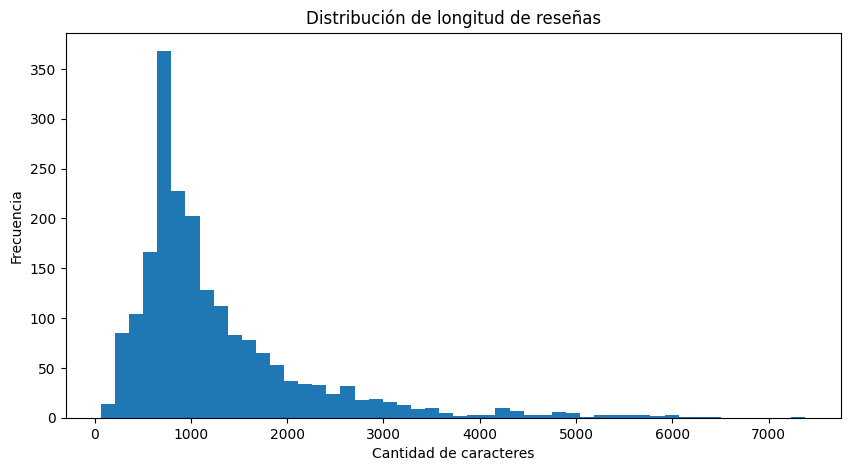

In [9]:
# Distribución de longitud de reviews

plt.figure(figsize=(10, 5))

plt.hist(df["review_length"], bins=50)

plt.title("Distribución de longitud de reseñas")
plt.xlabel("Cantidad de caracteres")
plt.ylabel("Frecuencia")

plt.show()

## Preprocesamiento NLP

In [10]:
# Stopwords

stop_words = set(stopwords.words("english"))

print(f"Cantidad de stopwords: {len(stop_words)}")

Cantidad de stopwords: 198


In [11]:
# Función de preprocesamiento

def preprocess_text(text):

    # Convertir a minúsculas
    text = text.lower()

    # Eliminar etiquetas HTML
    text = re.sub(r"<.*?>", " ", text)

    # Eliminar caracteres no alfabéticos
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Tokenización
    tokens = word_tokenize(text)

    # Eliminar stopwords y palabras cortas
    tokens = [
        word for word in tokens
        if word not in stop_words and len(word) > 2
    ]

    return tokens

In [14]:
# Aplicación de preprocesamiento

print("Procesando reseñas...")

df["tokens"] = df["text"].apply(preprocess_text)

print("Preprocesamiento completado.")

Procesando reseñas...
Preprocesamiento completado.


In [15]:
# Ejemplo de tokens

print(df["tokens"].iloc[0][:50])

['rented', 'curious', 'yellow', 'video', 'store', 'controversy', 'surrounded', 'first', 'released', 'also', 'heard', 'first', 'seized', 'customs', 'ever', 'tried', 'enter', 'country', 'therefore', 'fan', 'films', 'considered', 'controversial', 'really', 'see', 'plot', 'centered', 'around', 'young', 'swedish', 'drama', 'student', 'named', 'lena', 'wants', 'learn', 'everything', 'life', 'particular', 'wants', 'focus', 'attentions', 'making', 'sort', 'documentary', 'average', 'swede', 'thought', 'certain', 'political']


In [16]:
# Construcción del vocabulario

all_words = []

for tokens in df["tokens"]:
    all_words.extend(tokens)

print(f"Cantidad total de palabras: {len(all_words)}")

Cantidad total de palabras: 226354


In [17]:
# Palabras más frecuentes

word_counts = Counter(all_words)

most_common_words = word_counts.most_common(30)

print("Palabras más frecuentes:\n")

for word, count in most_common_words:
    print(f"{word}: {count}")

Palabras más frecuentes:

movie: 3850
film: 3071
one: 2082
like: 1735
even: 1153
good: 1151
bad: 1148
would: 1101
really: 982
time: 917
story: 840
see: 804
much: 783
get: 764
could: 758
made: 733
people: 717
make: 707
well: 679
plot: 657
character: 643
first: 639
movies: 624
way: 618
characters: 589
acting: 587
also: 570
think: 553
watch: 535
seen: 533


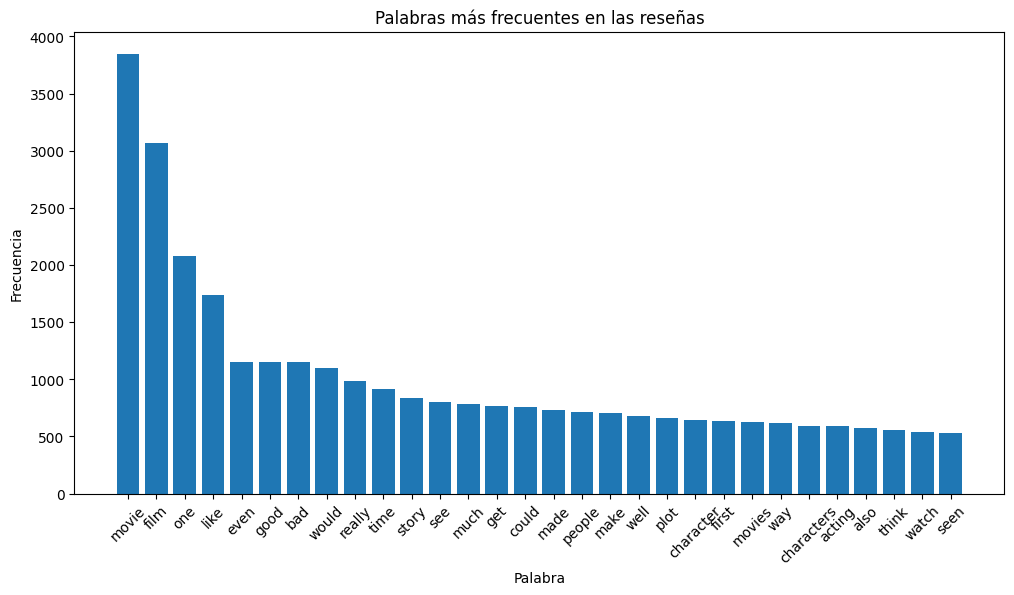

In [18]:
# Visualización de palabras frecuentes

common_words_df = pd.DataFrame(
    most_common_words,
    columns=["word", "count"]
)

plt.figure(figsize=(12, 6))

plt.bar(common_words_df["word"], common_words_df["count"])

plt.xticks(rotation=45)

plt.title("Palabras más frecuentes en las reseñas")
plt.xlabel("Palabra")
plt.ylabel("Frecuencia")

plt.show()

In [19]:
# Selección del vocabulario final

top_n_words = 250

selected_words = [
    word for word, count
    in word_counts.most_common(top_n_words)
]

print(f"Cantidad de palabras seleccionadas: {len(selected_words)}")

Cantidad de palabras seleccionadas: 250


In [20]:
# Ejemplo de palabras seleccionadas

print(selected_words[:50])

['movie', 'film', 'one', 'like', 'even', 'good', 'bad', 'would', 'really', 'time', 'story', 'see', 'much', 'get', 'could', 'made', 'people', 'make', 'well', 'plot', 'character', 'first', 'movies', 'way', 'characters', 'acting', 'also', 'think', 'watch', 'seen', 'better', 'two', 'know', 'ever', 'films', 'never', 'scene', 'nothing', 'many', 'something', 'man', 'little', 'scenes', 'end', 'thing', 'great', 'show', 'say', 'funny', 'watching']


## Carga de embeddings GloVe

In [21]:
# Carga de embeddings GloVe

print("Cargando embeddings GloVe...")

glove_model = api.load("glove-wiki-gigaword-100")

print("Embeddings cargados correctamente.")

Cargando embeddings GloVe...
[==================================================] 100.0% 128.1/128.1MB downloaded
Embeddings cargados correctamente.


In [22]:
# Información del modelo

print(f"Cantidad de palabras en el vocabulario: {len(glove_model.key_to_index)}")

print(f"Dimensión de embeddings: {glove_model.vector_size}")

Cantidad de palabras en el vocabulario: 400000
Dimensión de embeddings: 100


In [23]:
# Ejemplo de similitud semántica

similar_words = glove_model.most_similar("movie", topn=10)

print("Palabras similares a 'movie':\n")

for word, similarity in similar_words:
    print(f"{word}: {similarity:.4f}")

Palabras similares a 'movie':

film: 0.9055
movies: 0.8959
films: 0.8664
hollywood: 0.8240
comedy: 0.8141
drama: 0.7655
sequel: 0.7645
starring: 0.7474
remake: 0.7330
shows: 0.7167


In [24]:
# Filtrado de palabras válidas

valid_words = [
    word for word in selected_words
    if word in glove_model.key_to_index
]

print(f"Palabras válidas encontradas: {len(valid_words)}")

Palabras válidas encontradas: 250


In [25]:
# Ejemplo de palabras válidas

print(valid_words[:50])

['movie', 'film', 'one', 'like', 'even', 'good', 'bad', 'would', 'really', 'time', 'story', 'see', 'much', 'get', 'could', 'made', 'people', 'make', 'well', 'plot', 'character', 'first', 'movies', 'way', 'characters', 'acting', 'also', 'think', 'watch', 'seen', 'better', 'two', 'know', 'ever', 'films', 'never', 'scene', 'nothing', 'many', 'something', 'man', 'little', 'scenes', 'end', 'thing', 'great', 'show', 'say', 'funny', 'watching']


In [26]:
# Construcción de matriz de embeddings

embedding_vectors = []

for word in valid_words:
    embedding_vectors.append(glove_model[word])

X = np.array(embedding_vectors)

print(f"Shape de la matriz de embeddings: {X.shape}")

Shape de la matriz de embeddings: (250, 100)


In [27]:
# Ejemplo de embedding

print(f"Palabra: {valid_words[0]}")

print("\nPrimeras 10 dimensiones del embedding:\n")

print(X[0][:10])

Palabra: movie

Primeras 10 dimensiones del embedding:

[ 0.38251   0.14821   0.60601  -0.51533   0.43992   0.061053 -0.62716
 -0.025385  0.1643   -0.22101 ]


In [28]:
# Dataframe auxiliar

embeddings_df = pd.DataFrame(X)

embeddings_df["word"] = valid_words

print(embeddings_df.head())

         0         1        2        3         4         5        6         7  \
0  0.38251  0.148210  0.60601 -0.51533  0.439920  0.061053 -0.62716 -0.025385   
1  0.19916 -0.049702  0.24579 -0.32281  0.897680 -0.127800 -0.49506  0.208140   
2 -0.22557  0.494180  0.48610 -0.43320  0.137380  0.506170  0.26058  0.301030   
3 -0.26870  0.817080  0.69896 -0.72341  0.091566  0.195570 -0.52112 -0.243130   
4 -0.15308  0.631940  0.65512 -0.30706 -0.239190  0.137000 -0.29819 -0.140800   

          8        9  ...        91        92        93        94       95  \
0  0.164300 -0.22101  ...  0.071315  0.055586 -0.297570 -0.072659 -0.25596   
1 -0.200460 -0.20604  ... -0.448750 -0.074689 -0.144260  0.192520  0.27108   
2 -0.091486  0.10876  ...  0.132950 -0.180700 -0.118540 -0.829850  0.13784   
3 -0.447010 -0.27039  ... -0.463720 -0.065652 -0.061944 -0.572330 -0.46406   
4  0.360130 -0.13795  ... -0.284960 -0.148060 -0.121970 -0.850820 -0.16775   

        96        97        98       99   wo

## PCA (Principal Component Analysis)

In [29]:
# PCA para reducción de dimensionalidad

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

print(f"Shape original: {X.shape}")
print(f"Shape reducido con PCA: {X_pca.shape}")

Shape original: (250, 100)
Shape reducido con PCA: (250, 2)


In [30]:
# Varianza explicada

explained_variance = pca.explained_variance_ratio_

print("Varianza explicada por cada componente:\n")

for i, variance in enumerate(explained_variance):
    print(f"Componente {i+1}: {variance:.4f}")

print(f"\nVarianza total explicada: {sum(explained_variance):.4f}")

Varianza explicada por cada componente:

Componente 1: 0.1039
Componente 2: 0.0943

Varianza total explicada: 0.1982


In [31]:
# Dataframe PCA

pca_df = pd.DataFrame()

pca_df["word"] = valid_words
pca_df["PCA_1"] = X_pca[:, 0]
pca_df["PCA_2"] = X_pca[:, 1]

print(pca_df.head())

    word     PCA_1     PCA_2
0  movie  1.140246 -3.136232
1   film  2.358801 -3.151026
2    one  1.016954  1.059522
3   like -0.459026 -0.060283
4   even -0.545949  0.954390


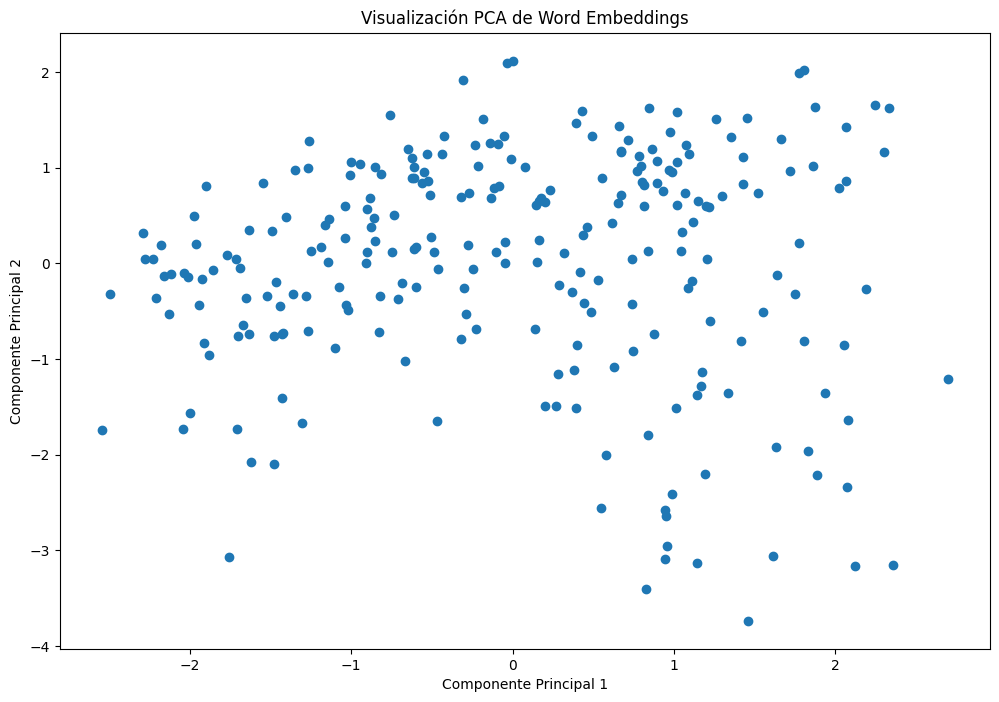

In [32]:
# Visualización PCA

plt.figure(figsize=(12, 8))

plt.scatter(
    pca_df["PCA_1"],
    pca_df["PCA_2"]
)

plt.title("Visualización PCA de Word Embeddings")

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")

plt.show()

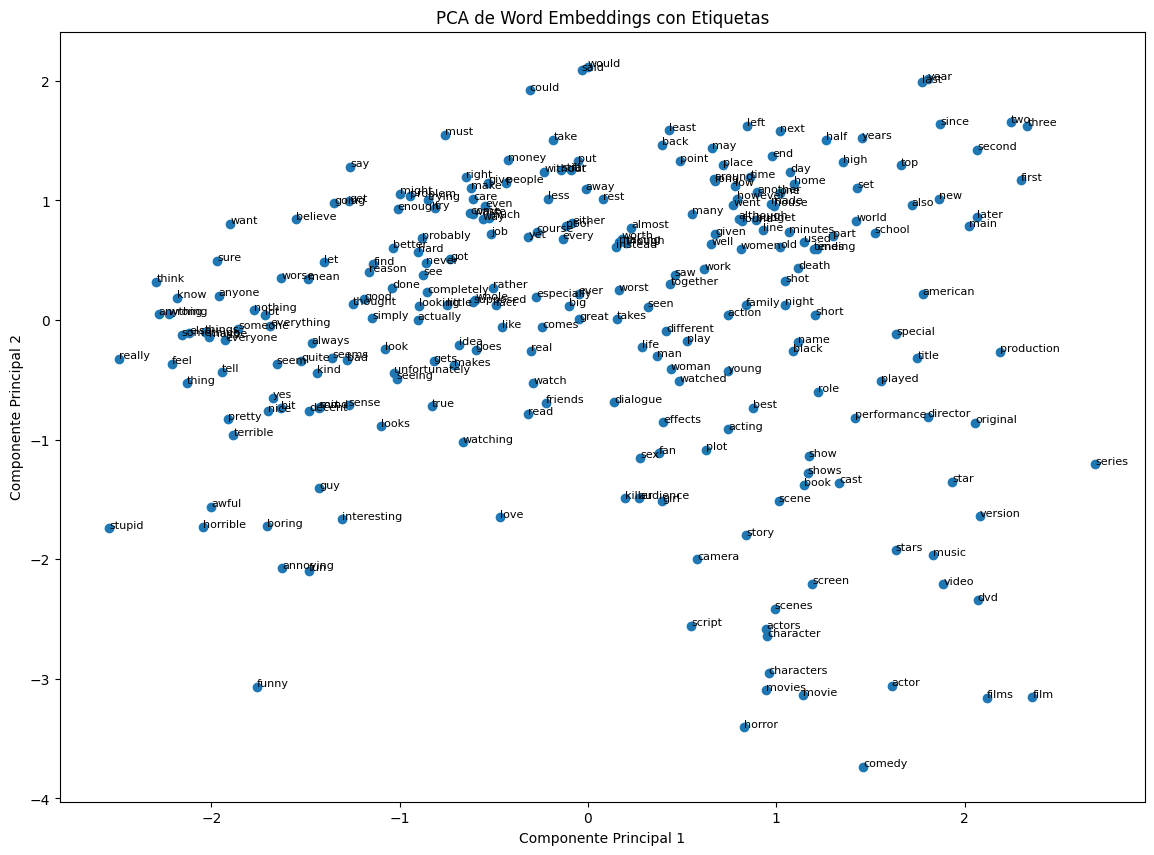

In [33]:
# PCA con etiquetas

plt.figure(figsize=(14, 10))

plt.scatter(
    pca_df["PCA_1"],
    pca_df["PCA_2"]
)

for i, word in enumerate(pca_df["word"]):
    plt.annotate(
        word,
        (pca_df["PCA_1"][i], pca_df["PCA_2"][i]),
        fontsize=8
    )

plt.title("PCA de Word Embeddings con Etiquetas")

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")

plt.show()

## Interpretación de resultados PCA

La visualización PCA permite observar cómo ciertas palabras tienden a agruparse semánticamente en regiones similares del espacio bidimensional.

PCA preserva principalmente la estructura global de los embeddings, permitiendo así identificar relaciones generales entre términos relacionados con sentimientos, géneros cinematográficos y vocabulario frecuente en reseñas de películas.

Sin embargo, debido a que PCA es un método lineal y la reducción se realiza desde 100 dimensiones hasta únicamente 2 dimensiones, parte de la información original se pierde durante el proceso.

## t-SNE (t-Distributed Stochastic Neighbor Embedding)

In [34]:
# Configuración t-SNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=RANDOM_STATE,
    max_iter=1000
)

In [35]:
# t-SNE para reducción de dimensionalidad

print("Aplicando t-SNE...")

X_tsne = tsne.fit_transform(X)

print("t-SNE completado.")

print(f"Shape reducido con t-SNE: {X_tsne.shape}")

Aplicando t-SNE...
t-SNE completado.
Shape reducido con t-SNE: (250, 2)


In [36]:
# Dataframe t-SNE

tsne_df = pd.DataFrame()

tsne_df["word"] = valid_words
tsne_df["TSNE_1"] = X_tsne[:, 0]
tsne_df["TSNE_2"] = X_tsne[:, 1]

print(tsne_df.head())

    word    TSNE_1     TSNE_2
0  movie -7.419181 -14.919643
1   film -7.199087 -14.695030
2    one -7.570811   4.300508
3   like  8.670609  -4.903497
4   even -1.230001   4.329218


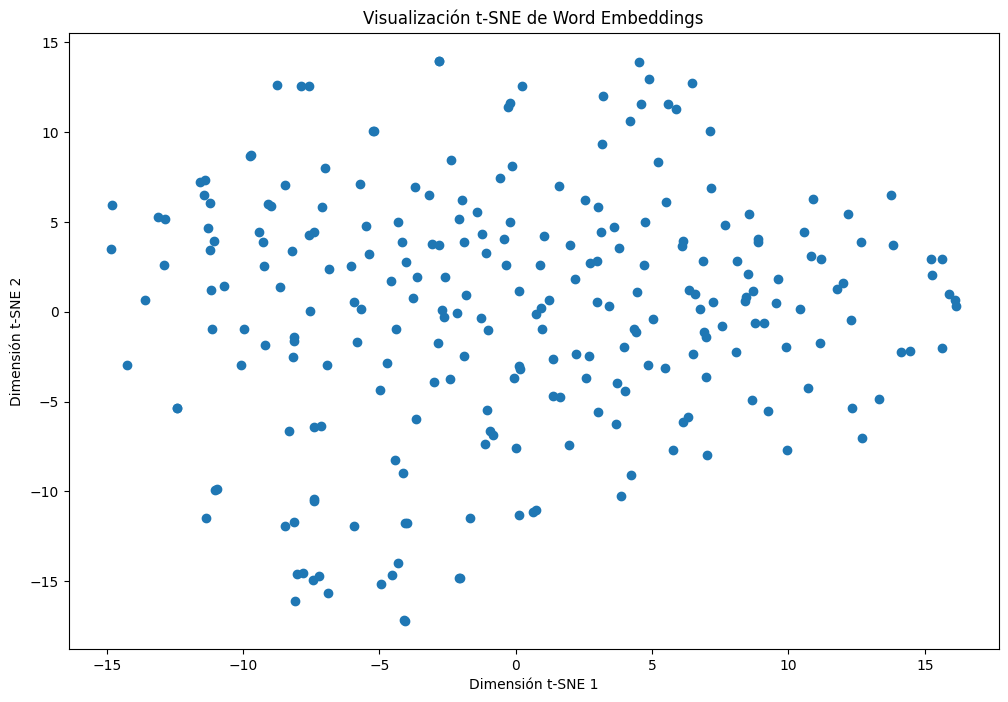

In [37]:
# Visualización t-SNE

plt.figure(figsize=(12, 8))

plt.scatter(
    tsne_df["TSNE_1"],
    tsne_df["TSNE_2"]
)

plt.title("Visualización t-SNE de Word Embeddings")

plt.xlabel("Dimensión t-SNE 1")
plt.ylabel("Dimensión t-SNE 2")

plt.show()

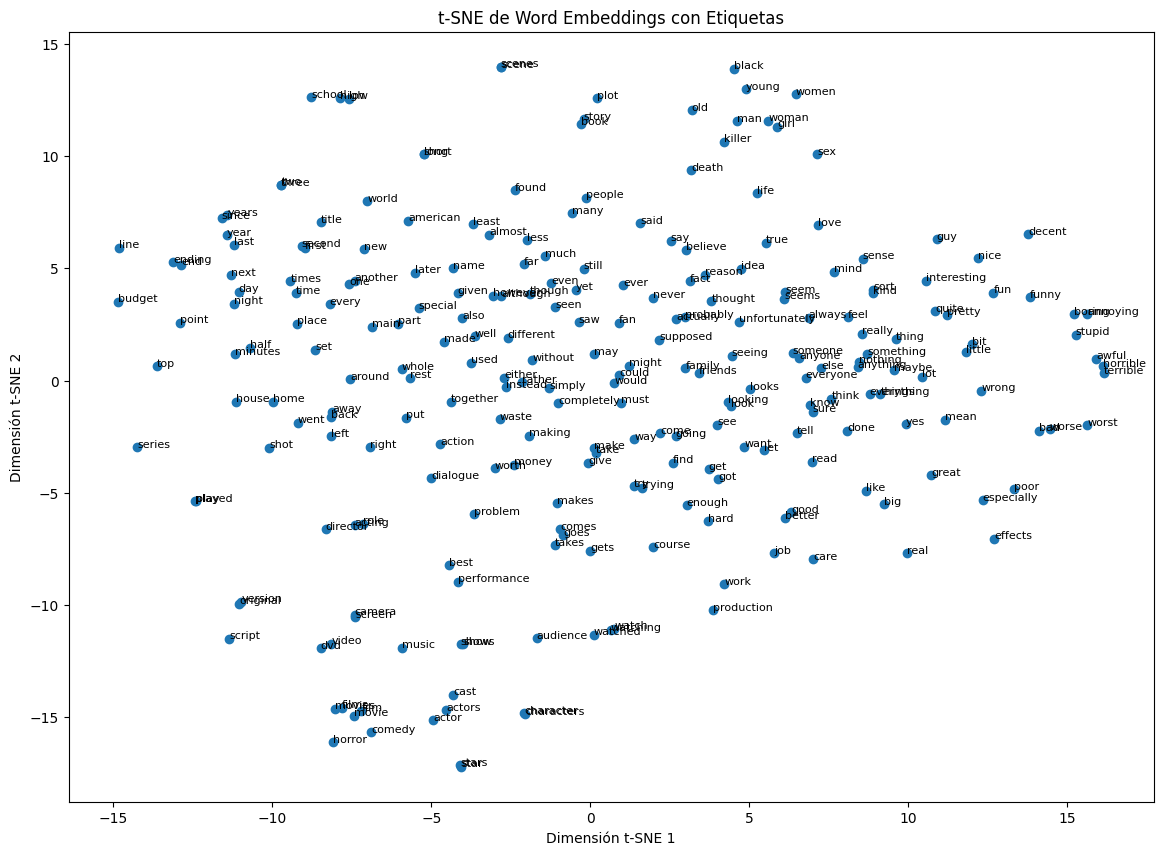

In [38]:
# t-SNE con etiquetas

plt.figure(figsize=(14, 10))

plt.scatter(
    tsne_df["TSNE_1"],
    tsne_df["TSNE_2"]
)

for i, word in enumerate(tsne_df["word"]):

    plt.annotate(
        word,
        (
            tsne_df["TSNE_1"][i],
            tsne_df["TSNE_2"][i]
        ),
        fontsize=8
    )

plt.title("t-SNE de Word Embeddings con Etiquetas")

plt.xlabel("Dimensión t-SNE 1")
plt.ylabel("Dimensión t-SNE 2")

plt.show()

## Comparación entre PCA y t-SNE

Los resultados obtenidos muestran diferencias importantes entre PCA y t-SNE.

PCA preserva principalmente la estructura global de los datos mediante una transformación lineal. Esto permite conservar parte de la varianza original de los embeddings, aunque puede dificultar la separación visual de grupos semánticos complejos.

Por otro lado, t-SNE utiliza una estrategia no lineal enfocada en preservar relaciones locales entre puntos cercanos. Como resultado, los clusters generados por t-SNE suelen mostrar una separación visual más clara entre palabras semánticamente relacionadas.

Sin embargo, t-SNE requiere mayor costo computacional y no preserva adecuadamente distancias globales entre clusters.

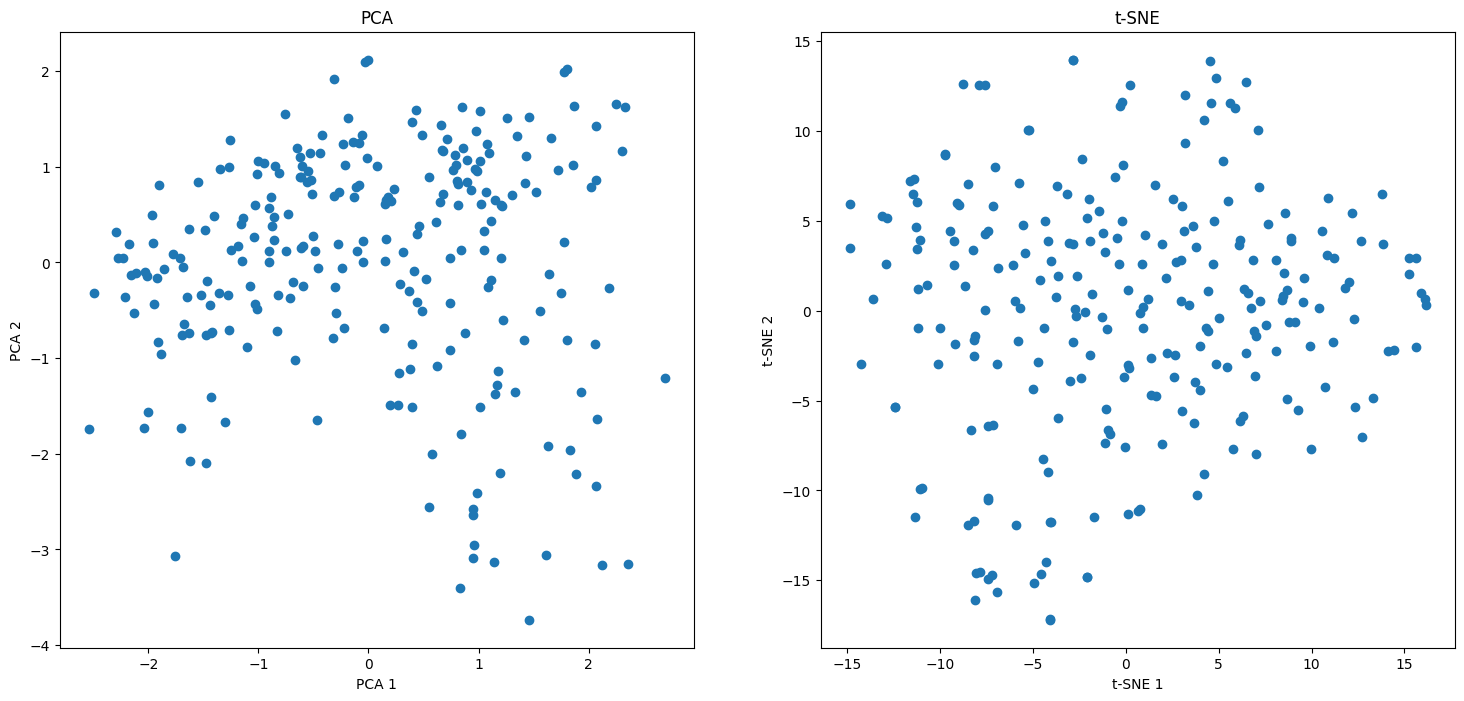

In [39]:
# Comparación visual PCA vs t-SNE

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# PCA
axes[0].scatter(
    pca_df["PCA_1"],
    pca_df["PCA_2"]
)

axes[0].set_title("PCA")

axes[0].set_xlabel("PCA 1")
axes[0].set_ylabel("PCA 2")

# t-SNE
axes[1].scatter(
    tsne_df["TSNE_1"],
    tsne_df["TSNE_2"]
)

axes[1].set_title("t-SNE")

axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")

plt.show()

## Clustering y evaluación

In [40]:
# Configuración de K-Means

n_clusters = 5

kmeans_pca = KMeans(
    n_clusters=n_clusters,
    random_state=RANDOM_STATE
)

kmeans_tsne = KMeans(
    n_clusters=n_clusters,
    random_state=RANDOM_STATE
)

In [41]:
# Clustering sobre PCA

pca_clusters = kmeans_pca.fit_predict(X_pca)

pca_df["cluster"] = pca_clusters

print("Clusters PCA generados correctamente.")

Clusters PCA generados correctamente.


In [42]:
# Clustering sobre t-SNE

tsne_clusters = kmeans_tsne.fit_predict(X_tsne)

tsne_df["cluster"] = tsne_clusters

print("Clusters t-SNE generados correctamente.")

Clusters t-SNE generados correctamente.


In [43]:
# Silhouette Score PCA

pca_silhouette = silhouette_score(
    X_pca,
    pca_clusters
)

print(f"Silhouette Score PCA: {pca_silhouette:.4f}")

Silhouette Score PCA: 0.4048


In [44]:
# Silhouette Score t-SNE

tsne_silhouette = silhouette_score(
    X_tsne,
    tsne_clusters
)

print(f"Silhouette Score t-SNE: {tsne_silhouette:.4f}")

Silhouette Score t-SNE: 0.3873


In [45]:
# Comparación de resultados

comparison_df = pd.DataFrame({
    "Método": ["PCA", "t-SNE"],
    "Silhouette Score": [
        pca_silhouette,
        tsne_silhouette
    ]
})

print(comparison_df)

  Método  Silhouette Score
0    PCA          0.404843
1  t-SNE          0.387341


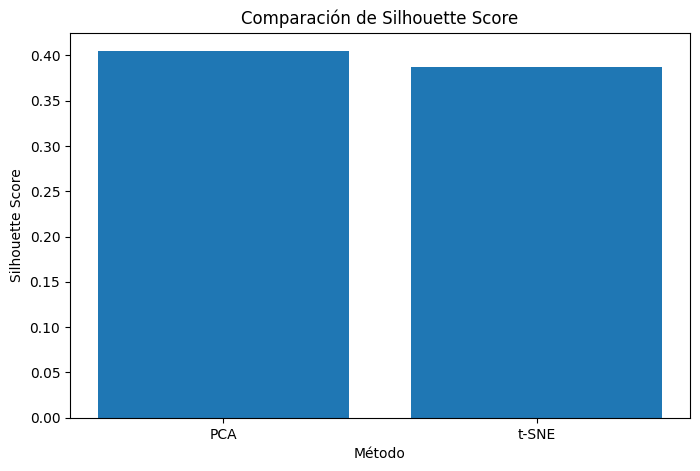

In [46]:
# Visualización de métricas

plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Método"],
    comparison_df["Silhouette Score"]
)

plt.title("Comparación de Silhouette Score")

plt.xlabel("Método")
plt.ylabel("Silhouette Score")

plt.show()

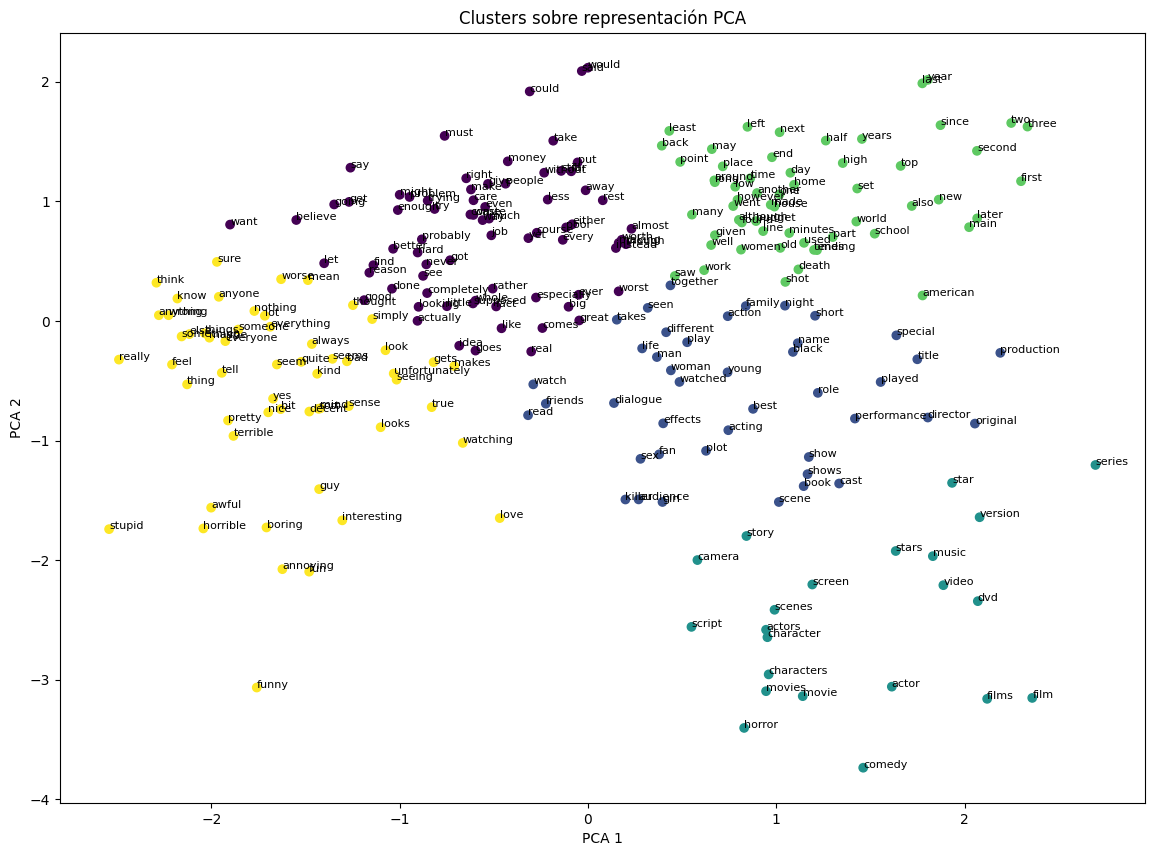

In [47]:
# PCA con Clusters

plt.figure(figsize=(14, 10))

scatter = plt.scatter(
    pca_df["PCA_1"],
    pca_df["PCA_2"],
    c=pca_df["cluster"]
)

for i, word in enumerate(pca_df["word"]):

    plt.annotate(
        word,
        (
            pca_df["PCA_1"][i],
            pca_df["PCA_2"][i]
        ),
        fontsize=8
    )

plt.title("Clusters sobre representación PCA")

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.show()

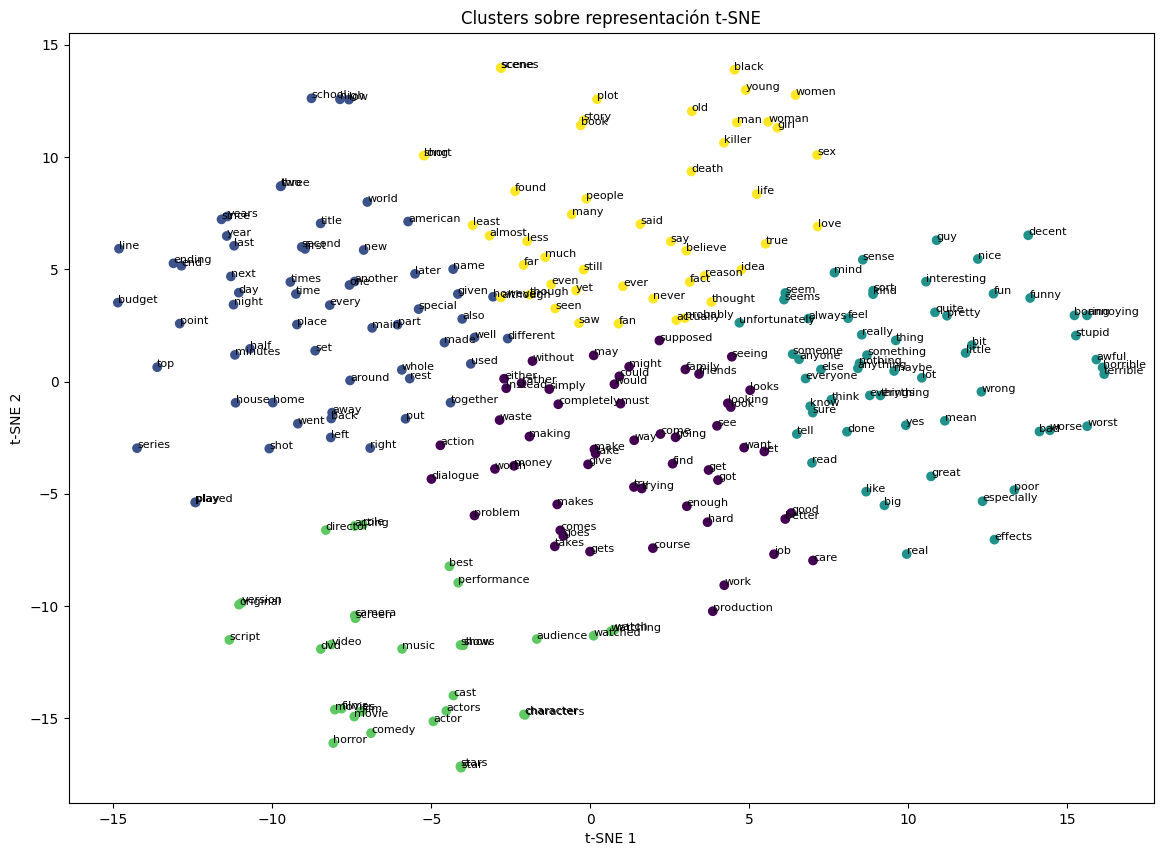

In [48]:
# t-SNE con Clusters

plt.figure(figsize=(14, 10))

scatter = plt.scatter(
    tsne_df["TSNE_1"],
    tsne_df["TSNE_2"],
    c=tsne_df["cluster"]
)

for i, word in enumerate(tsne_df["word"]):

    plt.annotate(
        word,
        (
            tsne_df["TSNE_1"][i],
            tsne_df["TSNE_2"][i]
        ),
        fontsize=8
    )

plt.title("Clusters sobre representación t-SNE")

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")

plt.show()

## Interpretación de resultados de clustering

Los resultados obtenidos mediante K-Means y Silhouette Score permiten comparar cuantitativamente la calidad de agrupamiento generada por PCA y t-SNE.

El método con mayor Silhouette Score presenta clusters más compactos y mejor separados, indicando una representación semántica más clara de las relaciones entre palabras.

En general, t-SNE tiende a generar agrupaciones visualmente más definidas debido a su capacidad para preservar relaciones locales entre embeddings similares. Sin embargo, PCA conserva mejor la estructura global de los datos y presenta menor costo computacional.

Los resultados obtenidos demuestran que ambas técnicas son útiles para la visualización de embeddings, aunque con diferentes fortalezas y limitaciones.

## Visualización más completa y Exportación

In [49]:
# PCA interactivo con Plotly

fig_pca = px.scatter(
    pca_df,
    x="PCA_1",
    y="PCA_2",
    color=pca_df["cluster"].astype(str),
    hover_name="word",
    title="Visualización Interactiva PCA",
    width=1000,
    height=700
)

fig_pca.show()

In [50]:
# t-SNE interactivo con Plotly

fig_tsne = px.scatter(
    tsne_df,
    x="TSNE_1",
    y="TSNE_2",
    color=tsne_df["cluster"].astype(str),
    hover_name="word",
    title="Visualización Interactiva t-SNE",
    width=1000,
    height=700
)

fig_tsne.show()

In [51]:
# Comparación interactiva de métricas

fig_metrics = px.bar(
    comparison_df,
    x="Método",
    y="Silhouette Score",
    color="Método",
    title="Comparación de Silhouette Score",
    width=700,
    height=500
)

fig_metrics.show()

In [52]:
# Palabras agrupadas por Cluster (t-SNE)

for cluster_id in sorted(tsne_df["cluster"].unique()):

    cluster_words = tsne_df[
        tsne_df["cluster"] == cluster_id
    ]["word"].tolist()

    print(f"\nCLUSTER {cluster_id}")
    print("-" * 40)

    print(cluster_words[:20])


CLUSTER 0
----------------------------------------
['good', 'would', 'see', 'get', 'could', 'make', 'way', 'better', 'going', 'got', 'want', 'look', 'work', 'give', 'take', 'enough', 'makes', 'find', 'gets', 'making']

CLUSTER 1
----------------------------------------
['one', 'time', 'made', 'well', 'first', 'also', 'two', 'end', 'another', 'every', 'back', 'part', 'minutes', 'around', 'new', 'point', 'however', 'years', 'away', 'whole']

CLUSTER 2
----------------------------------------
['like', 'bad', 'really', 'think', 'know', 'nothing', 'something', 'little', 'thing', 'great', 'funny', 'worst', 'real', 'guy', 'pretty', 'seems', 'big', 'lot', 'anything', 'interesting']

CLUSTER 3
----------------------------------------
['movie', 'film', 'character', 'movies', 'characters', 'acting', 'watch', 'films', 'show', 'watching', 'actors', 'director', 'script', 'horror', 'best', 'cast', 'original', 'comedy', 'music', 'role']

CLUSTER 4
----------------------------------------
['even', 'st

In [53]:
# Exportación de resultados PCA

pca_df.to_csv(
    "pca_results.csv",
    index=False
)

print("Archivo pca_results.csv exportado.")

Archivo pca_results.csv exportado.


In [54]:
# Exportación de resultados t-SNE

tsne_df.to_csv(
    "tsne_results.csv",
    index=False
)

print("Archivo tsne_results.csv exportado.")

Archivo tsne_results.csv exportado.


In [55]:
# Descarga de archivos (opcional)

from google.colab import files

files.download("pca_results.csv")
files.download("tsne_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Exportación de Gráficas (opcional)

fig_pca.write_html("pca_interactive.html")

fig_tsne.write_html("tsne_interactive.html")

print("Gráficas exportadas correctamente.")

# Conclusiones

- Se implementó correctamente un sistema inteligente para la visualización de word embeddings utilizando técnicas de reducción de dimensionalidad.

- Los embeddings preentrenados GloVe permitieron representar relaciones semánticas entre palabras presentes en reseñas cinematográficas.

- PCA logró preservar parte de la estructura global de los embeddings, permitiendo una representación bidimensional interpretable.

- t-SNE generó agrupaciones visuales más claras y compactas, facilitando la identificación de relaciones semánticas locales entre palabras similares.

- La evaluación mediante Silhouette Score permitió comparar cuantitativamente ambos métodos de reducción de dimensionalidad.

- Los resultados obtenidos demuestran que t-SNE suele producir mejores separaciones visuales para tareas de representación semántica, aunque requiere mayor costo computacional que PCA.